In [76]:
# import time

# import pandas as pd
# import requests

# # Descarga del dataset (solo ejecutar una vez)

# url = "https://ssd-api.jpl.nasa.gov/sbdb_query.api"

# fields = "pdes,full_name,diameter,diameter_sigma"

# # Total que ya conocemos
# total = 139582

# # Número de objetos por petición
# batch_size = 5000

# all_data = []

# for start in range(0, total, batch_size):

#     params = {
#         "sb-cdata": '{"AND":["diameter|DF"]}',
#         "fields": fields,
#         "limit": batch_size,
#         "limit-from": start,
#     }

#     print(f"Downloading objects {start:,} - "
#           f"{min(start + batch_size, total):,}...")

#     response = requests.get(url, params=params)
#     response.raise_for_status()

#     data = response.json()

#     all_data.extend(data["data"])

#     # Pequeña pausa entre solicitudes
#     time.sleep(1)

# print(f"Downloaded {len(all_data):,} objects.")

In [77]:
# # Conversión a dataframe y guardado (solo una vez)

# df = pd.DataFrame(
#     all_data,
#     columns=data["fields"]
# )

# df.to_csv(
#     "sbdb_diameters.csv",
#     index=False
# )

In [78]:
import pandas as pd

# Leer csv y mostrar las primeras filas
df = pd.read_csv("sbdb_diameters.csv")
df.head()

C:\Users\andre\AppData\Local\Temp\ipykernel_19752\2952689240.py:4: DtypeWarning: Columns (0: pdes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("sbdb_diameters.csv")


,pdes,full_name,diameter,diameter_sigma
0,1,1 Ceres (A801 AA),939.400,0.20
1,2,2 Pallas (A802 FA),513.000,6.00
2,3,3 Juno (A804 RA),246.596,10.59
3,4,4 Vesta (A807 FA),522.770,0.10
4,5,5 Astraea (A845 XA),106.699,3.14


In [79]:
# Describe
df.describe()

,diameter,diameter_sigma
count,139687.000000,139472.000000
mean,5.460632,0.486065
std,9.309314,0.798903
min,0.002500,-1.000000
25%,2.764000,0.180000
50%,3.950000,0.340000
75%,5.732000,0.630000
max,939.400000,140.000000


In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 139687 entries, 0 to 139686
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   pdes            139687 non-null  object 
 1   full_name       139687 non-null  str    
 2   diameter        139687 non-null  float64
 3   diameter_sigma  139472 non-null  float64
dtypes: float64(2), object(1), str(1)
memory usage: 4.3+ MB


In [81]:
# Count missing values in each column
df.isnull().sum()

pdes                0
full_name           0
diameter            0
diameter_sigma    215
dtype: int64

In [82]:
# Non-significant amount of missing values, therefore we eliminate them
df = df.dropna(subset=['diameter_sigma']).copy()

In [83]:
# Check duplicates based on the 'pdes' column
df[df.duplicated(subset='pdes', keep=False)]

,pdes,full_name,diameter,diameter_sigma


array([[<Axes: title={'center': 'diameter'}>,
        <Axes: title={'center': 'diameter_sigma'}>]], dtype=object)

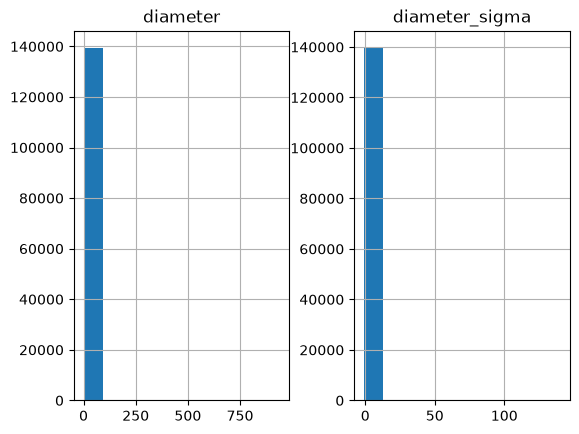

In [84]:
df.hist()

array([[<Axes: title={'center': 'diameter'}>,
        <Axes: title={'center': 'diameter_sigma'}>]], dtype=object)

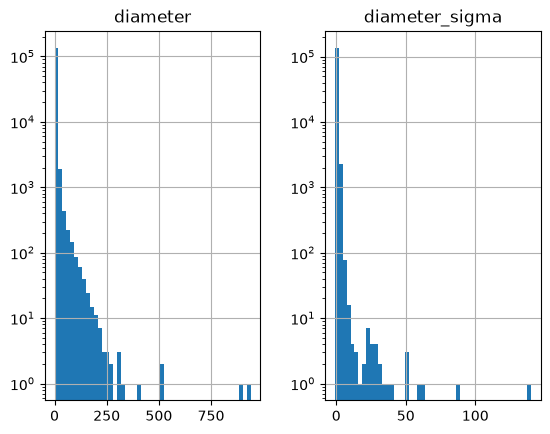

In [85]:
# Strong outliers demand a log scale for better visualization
df.hist(log=True, bins=50)

<Axes: >

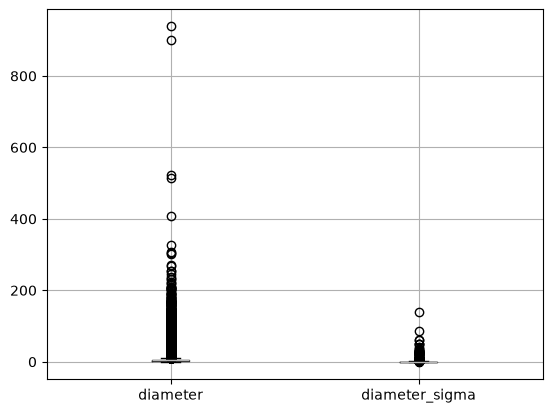

In [86]:
# Boxplots to check outliers
df.boxplot()

In [87]:
# Check relative uncertainty
df['relative_sigma'] = df['diameter_sigma'] / df['diameter']

array([[<Axes: title={'center': 'diameter'}>,
        <Axes: title={'center': 'diameter_sigma'}>],
       [<Axes: title={'center': 'relative_sigma'}>, <Axes: >]],
      dtype=object)

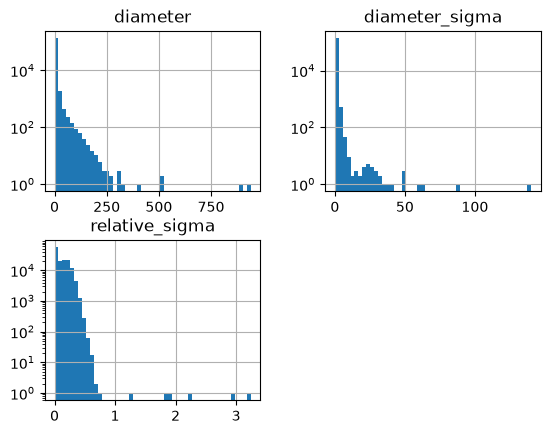

In [93]:
df.hist(log=True, bins=50)

In [89]:
# Extend the description
def super_description(df):
  uni = df.describe().drop('count')

  kurts = df.select_dtypes(
    include="number"
  ).kurtosis().to_frame().T.rename(
    index={0: "kurt"}
  )
  uni = pd.concat([uni, kurts])

  iqr = df.select_dtypes(
    include="number"
  ).apply(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
  ).to_frame().T.rename(
    index={0: "iqr"}
  )
  uni = pd.concat([uni, iqr])

  outliers = df.select_dtypes(
    include="number"
  ).apply(
    lambda x: (x < x.quantile(0.25) - 1.5 * x.quantile(0.75)) |
              (x > x.quantile(0.75) + 1.5 * x.quantile(0.25))
  ).sum().to_frame().T.rename(
    index={0: "outs"}
  )
  uni = pd.concat([uni, outliers])

  outliers_perc = df.select_dtypes(
    include="number"
  ).apply(
    lambda x: (x < x.quantile(0.25) - 1.5 * x.quantile(0.75)) |
              (x > x.quantile(0.75) + 1.5 * x.quantile(0.25))
  ).mean().to_frame().T.rename(
    index={0: "outs (%)"}
  ) * 100
  uni = pd.concat([uni, outliers_perc])

  display(uni)

super_description(df)

,diameter,diameter_sigma,relative_sigma
mean,5.441043,0.486065,0.127632
std,9.142136,0.798903,0.105188
min,0.002500,-1.000000,-0.004505
25%,2.765000,0.180000,0.035336
50%,3.951000,0.340000,0.098557
75%,5.732000,0.630000,0.206973
max,939.400000,140.000000,3.238843
kurt,1769.648966,8721.215751,11.264301
iqr,2.967000,0.450000,0.171637
outs,10408.000000,17917.000000,17925.000000


In [90]:
# Check negative sigmas
df.loc[
    df["diameter_sigma"] < 0,
    ["pdes", "full_name", "diameter", "diameter_sigma"]
]

,pdes,full_name,diameter,diameter_sigma
15,16,16 Psyche (A852 FA),222.0,-1.0


In [91]:
# Delete it as it is only one
df = df[df["diameter_sigma"] >= 0].copy()

In [92]:
super_description(df)

,diameter,diameter_sigma,relative_sigma
mean,5.439491,0.486075,0.127633
std,9.123760,0.798896,0.105188
min,0.002500,0.000000,0.000000
25%,2.765000,0.180000,0.035336
50%,3.951000,0.340000,0.098558
75%,5.731500,0.630000,0.206974
max,939.400000,140.000000,3.238843
kurt,1781.728653,8721.582464,11.264461
iqr,2.966500,0.450000,0.171638
outs,10407.000000,17916.000000,17925.000000


In [ ]:
# Objects per threshold

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.50, 1.00]

for threshold in thresholds:
    n = (df["relative_sigma"] <= threshold).sum()
    percentage = 100 * n / len(df)

    print(
        f"{threshold:.0%}: "
        f"{n:,} objects ({percentage:.2f}%)"
    )

5%: 48,132 objects (34.51%)
10%: 70,149 objects (50.30%)
15%: 84,678 objects (60.71%)
20%: 102,150 objects (73.24%)
25%: 118,710 objects (85.11%)
30%: 130,146 objects (93.31%)
50%: 139,339 objects (99.91%)
100%: 139,465 objects (100.00%)


In [95]:
# Quartiles per threshold

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.50]

for threshold in thresholds:

    filtered = df[
        df["relative_sigma"] <= threshold
    ]

    q25 = filtered["diameter"].quantile(0.25)
    q50 = filtered["diameter"].quantile(0.50)
    q75 = filtered["diameter"].quantile(0.75)

    print(
        f"{threshold:>5.0%} | "
        f"N = {len(filtered):>7,} | "
        f"Q25 = {q25:.3f} | "
        f"Median = {q50:.3f} | "
        f"Q75 = {q75:.3f}"
    )

   5% | N =  48,132 | Q25 = 4.391 | Median = 5.931 | Q75 = 8.333
  10% | N =  70,149 | Q25 = 3.957 | Median = 5.323 | Q75 = 7.401
  15% | N =  84,678 | Q25 = 3.489 | Median = 4.924 | Q75 = 6.943
  20% | N = 102,150 | Q25 = 3.067 | Median = 4.473 | Q75 = 6.435
  25% | N = 118,710 | Q25 = 2.858 | Median = 4.161 | Q75 = 6.062
  30% | N = 130,146 | Q25 = 2.788 | Median = 4.021 | Q75 = 5.867
  50% | N = 139,339 | Q25 = 2.765 | Median = 3.950 | Q75 = 5.732
